In [5]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from typing import List, Tuple, Dict

# evaluate.py must be in the SAME folder as this notebook
sys.path.insert(0, os.getcwd())
from evaluate import (
    aggregate_ground_truth_annotations,
    build_segment_frame_from_intervals,
    calculate_f1_score,
)
print("Imports OK.")

Imports OK.


In [7]:
PATH_TO_DATASET = ("C:\\Users\\syedw\\Downloads\\AI SS26\\mlpc2026\\UE\\Task5")

In [8]:
FEATURE_NAMES = [
    "zcr_mean","zcr_std","zcr_min","zcr_max",
    "melspect_mean","melspect_std","melspect_min","melspect_max",
    "mfcc_mean","mfcc_std","mfcc_min","mfcc_max",
    "mfcc_d_mean","mfcc_d_std","mfcc_d_min","mfcc_d_max",
    "mfcc_d2_mean","mfcc_d2_std","mfcc_d2_min","mfcc_d2_max",
    "flux_mean","flux_std","flux_min","flux_max",
    "flatness_mean","flatness_std","flatness_min","flatness_max",
    "centroid_mean","centroid_std","centroid_min","centroid_max",
    "bandwidth_mean","bandwidth_std","bandwidth_min","bandwidth_max",
    "contrast_mean","contrast_std","contrast_min","contrast_max",
    "rolloff_low_mean","rolloff_low_std","rolloff_low_min","rolloff_low_max",
    "rolloff_high_mean","rolloff_high_std","rolloff_high_min","rolloff_high_max",
    "energy_mean","energy_std","energy_min","energy_max",
    "power_mean","power_std","power_min","power_max",
]

CLASS_NAMES = [
    "bell_ringing","coffee_machine","cutlery_dishes","door_open_close","footsteps",
    "keyboard_typing","keychain","light_switch","microwave","phone_ringing",
    "running_water","toilet_flushing","vacuum_cleaner","wardrobe_drawer_open_close","window_open_close",
]

SEGMENT_LENGTH = 1.0   # each feature window covers 1 second
HOP_SIZE       = 0.5   # 50% overlap between consecutive segments

print(f"{len(FEATURE_NAMES)} feature arrays, {len(CLASS_NAMES)} classes.")

56 feature arrays, 15 classes.


In [9]:
BASE = r"C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5"

def find_dataset_root(base):
    candidates = [base] + [os.path.join(base, d) for d in os.listdir(base)
                           if os.path.isdir(os.path.join(base, d))]
    for c in candidates:
        if all(os.path.isdir(os.path.join(c, s)) for s in ["train", "validation", "test"]):
            return c
    return None

PATH_TO_DATASET = find_dataset_root(BASE)
assert PATH_TO_DATASET is not None, "Could not find train/validation/test under Task5."
print("Dataset root:", PATH_TO_DATASET)

PATH_TRAIN = os.path.join(PATH_TO_DATASET, "train")
PATH_VAL   = os.path.join(PATH_TO_DATASET, "validation")
PATH_TEST  = os.path.join(PATH_TO_DATASET, "test")

for path in [
    os.path.join(PATH_TRAIN, "annotations.csv"),
    os.path.join(PATH_TRAIN, "audio_features"),
    os.path.join(PATH_VAL,   "annotations.csv"),
    os.path.join(PATH_VAL,   "audio_features"),
    os.path.join(PATH_TEST,  "audio_features"),
]:
    assert os.path.exists(path), f"Path not found: {path}"
print("Dataset paths OK.")

Dataset root: C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5
Dataset paths OK.


In [10]:
train_files = sorted(glob.glob(os.path.join(PATH_TRAIN, "audio_features", "*.npz")))
val_files   = sorted(glob.glob(os.path.join(PATH_VAL,   "audio_features", "*.npz")))
test_files  = sorted(glob.glob(os.path.join(PATH_TEST,  "audio_features", "*.npz")))

print(f"Training recordings:   {len(train_files)}")
print(f"Validation recordings: {len(val_files)}")
print(f"Test recordings:       {len(test_files)}  (hidden)")

Training recordings:   3704
Validation recordings: 999
Test recordings:       1007  (hidden)


In [11]:
rng = np.random.default_rng(seed=42)

val_files_shuffled = rng.permutation(val_files).tolist()
n_val = len(val_files_shuffled) // 2

our_val_files  = val_files_shuffled[:n_val]   # for tuning
our_test_files = val_files_shuffled[n_val:]   # final estimate only — don't tune on this

print(f"Local validation set:  {len(our_val_files)}")
print(f"Non-hidden test set:   {len(our_test_files)}")
print(f"Hidden test set:       {len(test_files)}")

Local validation set:  499
Non-hidden test set:   500
Hidden test set:       1007


In [12]:
def build_feature_matrix(data: dict) -> np.ndarray:
    """Concatenate all 960 features from one .npz into a (N_segments, 960) matrix."""
    arrays = []
    for feat_name in FEATURE_NAMES:
        feat = data[feat_name]
        if feat.ndim == 1:
            feat = feat[:, np.newaxis]
        arrays.append(feat.astype(np.float32))
    return np.concatenate(arrays, axis=1)


def get_segment_labels(data: dict) -> np.ndarray:
    """Binary multilabel targets from annotations of shape (N, C, A).
       Baseline rule: active if ANY overlap (>0), then majority vote across annotators."""
    annotations = data["annotations"]          # (N, C, A)
    binary = (annotations > 0).astype(int)     # any overlap counts
    votes = binary.sum(axis=2)                 # (N, C)
    n_annotators = binary.shape[2]
    y = (votes > (n_annotators // 2)).astype(int)
    return y


def load_all_segments(file_list: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """Stack features and labels from many .npz files."""
    X_list, Y_list = [], []
    for filepath in file_list:
        data = dict(np.load(filepath, allow_pickle=True))
        X_list.append(build_feature_matrix(data))
        Y_list.append(get_segment_labels(data))
    return np.vstack(X_list), np.vstack(Y_list)

print("Loading functions defined.")

Loading functions defined.


In [13]:
# Baseline settings (same as the provided baseline)
MAX_TRAINING_FILES    = None     # use all 3704 training recordings
MAX_TRAINING_SEGMENTS = 50_000   # subsample segments to keep tree training fast

print(f"Loading features from {len(train_files)} training recordings...")
X_train, Y_train = load_all_segments(train_files)
print(f"Loaded {X_train.shape[0]} segments × {X_train.shape[1]} features.")

if MAX_TRAINING_SEGMENTS is not None and X_train.shape[0] > MAX_TRAINING_SEGMENTS:
    idx = rng.choice(X_train.shape[0], size=MAX_TRAINING_SEGMENTS, replace=False)
    X_train = X_train[idx]
    Y_train = Y_train[idx]
    print(f"Subsampled to {X_train.shape[0]} segments.")

print("\nClass distribution (fraction of segments active):")
for i, cls in enumerate(CLASS_NAMES):
    frac = Y_train[:, i].mean()
    print(f"  {cls:<30} {frac:.4f}")

print("\nTraining baseline DecisionTree (one per class via MultiOutputClassifier)...")
base_clf = DecisionTreeClassifier(max_depth=20, max_features="sqrt", random_state=42)
clf = MultiOutputClassifier(base_clf, n_jobs=-1)
clf.fit(X_train, Y_train)
print(f"Done. Fitted {len(clf.estimators_)} trees.")

Loading features from 3704 training recordings...
Loaded 170508 segments × 960 features.
Subsampled to 50000 segments.

Class distribution (fraction of segments active):
  bell_ringing                   0.0152
  coffee_machine                 0.0384
  cutlery_dishes                 0.0793
  door_open_close                0.0552
  footsteps                      0.1438
  keyboard_typing                0.1038
  keychain                       0.0579
  light_switch                   0.0161
  microwave                      0.0749
  phone_ringing                  0.0757
  running_water                  0.1359
  toilet_flushing                0.0343
  vacuum_cleaner                 0.0674
  wardrobe_drawer_open_close     0.0305
  window_open_close              0.0209

Training baseline DecisionTree (one per class via MultiOutputClassifier)...
Done. Fitted 15 trees.


In [17]:
def run_sed_inference(filepath: str, classifier) -> Tuple[np.ndarray, np.ndarray, str]:
    """Predict on all segments of one recording, keep only whole-second segments."""
    data = dict(np.load(filepath, allow_pickle=True))
    start_times_all = data["start_time"]            # [0.0, 0.5, 1.0, ...]
    X_all = build_feature_matrix(data)
    pred_all = classifier.predict(X_all)            # (N_all, C)

    whole_second_mask = np.isclose(start_times_all % 1.0, 0.0)  # keep 0.0,1.0,2.0...
    predictions = pred_all[whole_second_mask]
    start_times = start_times_all[whole_second_mask]
    filename = os.path.basename(filepath).replace(".npz", ".wav")
    return predictions, start_times, filename


def predictions_to_intervals(predictions, start_times, filename) -> List[Dict]:
    """Merge consecutive active 1-second segments into onset/offset intervals."""
    rows = []
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_preds = predictions[:, cls_idx]
        in_event, onset = False, None
        for t, pred in zip(start_times, cls_preds):
            if pred == 1 and not in_event:
                onset, in_event = float(t), True
            elif pred == 0 and in_event:
                rows.append({"filename": filename, "annotation": cls_name,
                             "onset": onset, "offset": float(t)})
                in_event = False
        if in_event:  # event still active at end of recording
            rows.append({"filename": filename, "annotation": cls_name,
                         "onset": onset, "offset": float(start_times[-1]) + SEGMENT_LENGTH})
    return rows


def generate_predictions(file_list, classifier) -> pd.DataFrame:
    all_rows = []
    for filepath in file_list:
        preds, times, fname = run_sed_inference(filepath, classifier)
        all_rows.extend(predictions_to_intervals(preds, times, fname))
    if not all_rows:
        return pd.DataFrame(columns=["filename", "annotation", "onset", "offset"])
    return pd.DataFrame(all_rows)

print("Inference functions defined.")

Inference functions defined.


In [18]:
ann_df = pd.read_csv(os.path.join(PATH_VAL, "annotations.csv"))
print(f"Loaded {len(ann_df)} annotation rows for {ann_df['filename'].nunique()} recordings.")

def evaluate_split(pred_df, file_list, ann_df):
    """Official segment-based macro F1 for a split, using evaluate.py internals."""
    split_filenames = {os.path.basename(f).replace(".npz", ".wav") for f in file_list}
    ann_split = ann_df[ann_df["filename"].isin(split_filenames)].copy()
    gt = aggregate_ground_truth_annotations(ann_split)
    gt_segments   = build_segment_frame_from_intervals(gt,      name="ground_truth")
    pred_segments = build_segment_frame_from_intervals(pred_df, name="predictions")
    if len(pred_segments) > 0:
        pf = pred_segments.index.get_level_values("filename")
        pred_segments = pred_segments[pf.isin(split_filenames)]
    return calculate_f1_score(gt_segments, pred_segments)

print("\nGenerating baseline predictions for the non-hidden test set...")
pred_nht_df = generate_predictions(our_test_files, clf)
print(f"  {len(pred_nht_df)} event intervals predicted.")

macro_f1_nht, results_nht = evaluate_split(pred_nht_df, our_test_files, ann_df)

print(f"\n=== BASELINE — Non-Hidden Test Macro F1: {macro_f1_nht:.4f} ===\n")
print(results_nht.to_string(index=False))

Loaded 12233 annotation rows for 999 recordings.

Generating baseline predictions for the non-hidden test set...
  8022 event intervals predicted.

=== BASELINE — Non-Hidden Test Macro F1: 0.3170 ===

                annotation  precision   recall       f1  map
              bell_ringing   0.426087 0.217778 0.288235 None
            coffee_machine   0.503741 0.282517 0.362007 None
            cutlery_dishes   0.294053 0.280757 0.287251 None
           door_open_close   0.200265 0.159115 0.177334 None
                 footsteps   0.384265 0.293426 0.332757 None
           keyboard_typing   0.372093 0.346709 0.358953 None
                  keychain   0.364985 0.286713 0.321149 None
              light_switch   0.239837 0.227799 0.233663 None
                 microwave   0.407911 0.372881 0.389610 None
             phone_ringing   0.533969 0.444004 0.484848 None
             running_water   0.655000 0.516511 0.577570 None
           toilet_flushing   0.288425 0.292308 0.290353 None
      

In [19]:
def load_whole_second(file_list):
    """Whole-second segments + labels for a list of files (used for fast hyperparameter eval)."""
    Xs, Ys = [], []
    for fp in file_list:
        data = dict(np.load(fp, allow_pickle=True))
        mask = np.isclose(data["start_time"] % 1.0, 0.0)
        Xs.append(build_feature_matrix(data)[mask])
        Ys.append(get_segment_labels(data)[mask])
    return np.vstack(Xs), np.vstack(Ys)

X_val_ws, Y_val_ws = load_whole_second(our_val_files)
print(f"Val whole-second segments: {X_val_ws.shape[0]} × {X_val_ws.shape[1]}")

Val whole-second segments: 11823 × 960


  min_samples_leaf=1, max_depth=10: segment macro F1 = 0.4704
  min_samples_leaf=1, max_depth=20: segment macro F1 = 0.4633
  min_samples_leaf=1, max_depth=30: segment macro F1 = 0.4125
  min_samples_leaf=5, max_depth=10: segment macro F1 = 0.4720
  min_samples_leaf=5, max_depth=20: segment macro F1 = 0.4818
  min_samples_leaf=5, max_depth=30: segment macro F1 = 0.4512

Best: min_samples_leaf=5, max_depth=20, val macro F1=0.4818


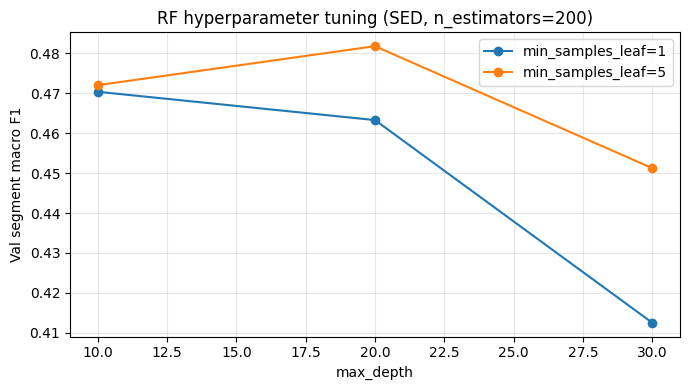

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

depths = [10, 20, 30]
leaves = [1, 5]          # min_samples_leaf: 5 was your Task 4 best; 1 = unconstrained
N_ESTIMATORS = 200       # fixed, as in Task 4

results = []
for leaf in leaves:
    for d in depths:
        rf = MultiOutputClassifier(
            RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=d,
                                   min_samples_leaf=leaf,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1))
        rf.fit(X_train, Y_train)
        Yp = rf.predict(X_val_ws)
        mf1 = f1_score(Y_val_ws, Yp, average='macro', zero_division=0)
        results.append({'min_samples_leaf': leaf, 'max_depth': d, 'val_macro_f1': mf1})
        print(f"  min_samples_leaf={leaf}, max_depth={d}: segment macro F1 = {mf1:.4f}")

res_df = pd.DataFrame(results)
best = res_df.loc[res_df['val_macro_f1'].idxmax()]
print(f"\nBest: min_samples_leaf={int(best['min_samples_leaf'])}, "
      f"max_depth={int(best['max_depth'])}, val macro F1={best['val_macro_f1']:.4f}")

fig, ax = plt.subplots(figsize=(7,4))
for leaf in leaves:
    sub = res_df[res_df['min_samples_leaf']==leaf]
    ax.plot(sub['max_depth'], sub['val_macro_f1'], marker='o', label=f'min_samples_leaf={leaf}')
ax.set_xlabel('max_depth'); ax.set_ylabel('Val segment macro F1')
ax.set_title('RF hyperparameter tuning (SED, n_estimators=200)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('rf_tuning.png', dpi=150); plt.show()

In [21]:
# Best config from validation sweep
BEST_DEPTH = 20
BEST_LEAF  = 5

print(f"Training final RF: max_depth={BEST_DEPTH}, min_samples_leaf={BEST_LEAF}, "
      f"n_estimators=200, class_weight='balanced'...")
rf_clf = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, max_depth=BEST_DEPTH,
                           min_samples_leaf=BEST_LEAF,
                           class_weight='balanced',
                           random_state=42, n_jobs=-1))
rf_clf.fit(X_train, Y_train)
print("Done.")

# Full SED inference on the non-hidden test set (official metric)
print("\nGenerating RF predictions for the non-hidden test set...")
pred_nht_rf = generate_predictions(our_test_files, rf_clf)
print(f"  {len(pred_nht_rf)} event intervals predicted.")

macro_f1_rf, results_rf = evaluate_split(pred_nht_rf, our_test_files, ann_df)

print(f"\n=== RANDOM FOREST — Non-Hidden Test Macro F1: {macro_f1_rf:.4f} ===")
print(f"    (Baseline decision tree was: 0.3170)")
print()

# Side-by-side per-class comparison
comp = results_rf[['annotation','f1']].rename(columns={'f1':'rf_f1'})
comp = comp.merge(results_nht[['annotation','f1']].rename(columns={'f1':'baseline_f1'}),
                  on='annotation')
comp['delta'] = comp['rf_f1'] - comp['baseline_f1']
comp = comp.sort_values('delta', ascending=False)
print(comp.to_string(index=False))

Training final RF: max_depth=20, min_samples_leaf=5, n_estimators=200, class_weight='balanced'...
Done.

Generating RF predictions for the non-hidden test set...
  4047 event intervals predicted.

=== RANDOM FOREST — Non-Hidden Test Macro F1: 0.4714 ===
    (Baseline decision tree was: 0.3170)

                annotation    rf_f1  baseline_f1     delta
              light_switch 0.483627     0.233663  0.249964
           toilet_flushing 0.520855     0.290353  0.230501
                 microwave 0.608635     0.389610  0.219025
           keyboard_typing 0.569709     0.358953  0.210756
            cutlery_dishes 0.489362     0.287251  0.202110
           door_open_close 0.370115     0.177334  0.192781
                  keychain 0.495913     0.321149  0.174764
wardrobe_drawer_open_close 0.291824     0.120267  0.171557
            vacuum_cleaner 0.636879     0.469742  0.167136
                 footsteps 0.488189     0.332757  0.155432
         window_open_close 0.205882     0.061093  0.144

In [22]:
# Build per-file ground-truth (whole-second) for our_test_files so we can pick interesting cases.
def file_gt_whole(fp):
    data = dict(np.load(fp, allow_pickle=True))
    mask = np.isclose(data["start_time"] % 1.0, 0.0)
    return get_segment_labels(data)[mask]

# Count true classes present per file, to find files with several active classes (more interesting)
file_info = []
for fp in our_test_files:
    gt = file_gt_whole(fp)
    n_classes = (gt.sum(axis=0) > 0).sum()
    n_seconds = gt.shape[0]
    file_info.append((os.path.basename(fp).replace('.npz','.wav'), fp, n_classes, n_seconds))

info_df = pd.DataFrame(file_info, columns=['fname','path','n_classes','n_seconds'])
# Prefer files with 3-5 active classes and a reasonable length (10-30 s)
candidates = info_df[(info_df.n_classes.between(3,5)) & (info_df.n_seconds.between(10,30))]
print(f"{len(candidates)} candidate files with 3-5 classes and 10-30 s.")
print(candidates.head(10).to_string(index=False))

251 candidate files with 3-5 classes and 10-30 s.
     fname                                                                                    path  n_classes  n_seconds
002101.wav C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\002101.npz          3         20
003835.wav C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\003835.npz          3         15
000301.wav C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\000301.npz          4         19
003867.wav C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\003867.npz          3         25
002184.wav C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\002184.npz          4         22
003227.wav C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\003227.npz          3         17
002187.wav C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\002187.npz     

In [23]:
SUCCESS_CLASSES = ['running_water','vacuum_cleaner','microwave','keyboard_typing','phone_ringing']
CONFUSE_CLASSES = ['door_open_close','wardrobe_drawer_open_close','window_open_close']

success_idx = [CLASS_NAMES.index(c) for c in SUCCESS_CLASSES]
confuse_idx = [CLASS_NAMES.index(c) for c in CONFUSE_CLASSES]

rows = []
for _, r in candidates.iterrows():
    gt = file_gt_whole(r['path'])
    present = gt.sum(axis=0) > 0
    n_success = sum(present[i] for i in success_idx)
    n_confuse = sum(present[i] for i in confuse_idx)
    active = [CLASS_NAMES[i] for i in range(15) if present[i]]
    rows.append({'fname': r['fname'], 'path': r['path'],
                 'n_success': n_success, 'n_confuse': n_confuse,
                 'classes': ', '.join(active)})
rank_df = pd.DataFrame(rows)

print(">>> Best SUCCESS candidates (distinctive, easy classes):")
print(rank_df.sort_values('n_success', ascending=False).head(5)[['fname','classes']].to_string(index=False))
print("\n>>> Best CONFUSION candidates (mechanical transient classes):")
print(rank_df.sort_values('n_confuse', ascending=False).head(5)[['fname','classes']].to_string(index=False))

>>> Best SUCCESS candidates (distinctive, easy classes):
     fname                                                classes
005110.wav         keyboard_typing, phone_ringing, vacuum_cleaner
000790.wav                microwave, phone_ringing, running_water
000308.wav           phone_ringing, running_water, vacuum_cleaner
004550.wav       phone_ringing, vacuum_cleaner, window_open_close
002188.wav coffee_machine, light_switch, microwave, running_water

>>> Best CONFUSION candidates (mechanical transient classes):
     fname                                                                        classes
003708.wav   cutlery_dishes, door_open_close, footsteps, running_water, window_open_close
005104.wav                       footsteps, wardrobe_drawer_open_close, window_open_close
005294.wav    door_open_close, running_water, toilet_flushing, wardrobe_drawer_open_close
003497.wav                       footsteps, wardrobe_drawer_open_close, window_open_close
001442.wav door_open_close, footst

In [24]:
def visualize_file(filepath, classifier, save_name=None):
    data = dict(np.load(filepath, allow_pickle=True))
    start_all = data["start_time"]
    mask = np.isclose(start_all % 1.0, 0.0)

    gt = get_segment_labels(data)[mask]                       # (T, 15)
    X_all = build_feature_matrix(data)
    pred = classifier.predict(X_all)[mask]                    # (T, 15)
    times = start_all[mask]
    fname = os.path.basename(filepath).replace('.npz','.wav')

    # only show classes that are active in GT or prediction (keeps plot readable)
    active = np.where((gt.sum(0) > 0) | (pred.sum(0) > 0))[0]
    labels = [CLASS_NAMES[i] for i in active]

    mel_log = np.log1p(data["melspect_mean"].T)               # (128, N_all)
    t_edges_all = np.append(start_all, start_all[-1] + HOP_SIZE)
    t_edges_ws  = np.append(times, float(times[-1]) + SEGMENT_LENGTH)
    mel_edges = np.arange(mel_log.shape[0] + 1) - 0.5
    cls_edges = np.arange(len(active) + 1) - 0.5

    fig, axes = plt.subplots(3, 1, figsize=(14, 9),
                             gridspec_kw={"height_ratios":[2,1.4,1.4]}, sharex=True)
    fig.suptitle(f"{fname}", fontsize=12, fontweight="bold")

    axes[0].pcolormesh(t_edges_all, mel_edges, mel_log, cmap="magma", shading="flat")
    axes[0].set_ylabel("Mel bin"); axes[0].set_title("Log mel spectrogram")

    axes[1].pcolormesh(t_edges_ws, cls_edges, gt[:, active].T, cmap="Greens", vmin=0, vmax=1, shading="flat")
    axes[1].set_yticks(range(len(active))); axes[1].set_yticklabels(labels, fontsize=8)
    axes[1].invert_yaxis(); axes[1].set_title("Ground Truth"); axes[1].set_ylabel("Class")

    axes[2].pcolormesh(t_edges_ws, cls_edges, pred[:, active].T, cmap="Blues", vmin=0, vmax=1, shading="flat")
    axes[2].set_yticks(range(len(active))); axes[2].set_yticklabels(labels, fontsize=8)
    axes[2].invert_yaxis(); axes[2].set_title("Predictions (RF)"); axes[2].set_ylabel("Class")
    axes[2].set_xlabel("Time (s)")

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches="tight")
        print(f"Saved {save_name}")
    plt.show()

    # quick text summary of hits/misses/false-alarms
    print(f"\n{fname} — per active class:")
    for i in active:
        tp = int(((gt[:,i]==1)&(pred[:,i]==1)).sum())
        fn = int(((gt[:,i]==1)&(pred[:,i]==0)).sum())
        fp = int(((gt[:,i]==0)&(pred[:,i]==1)).sum())
        print(f"  {CLASS_NAMES[i]:<28} TP={tp} FN={fn} FP={fp}")

print("visualize_file ready.")

visualize_file ready.


Saved case_success_000790.png


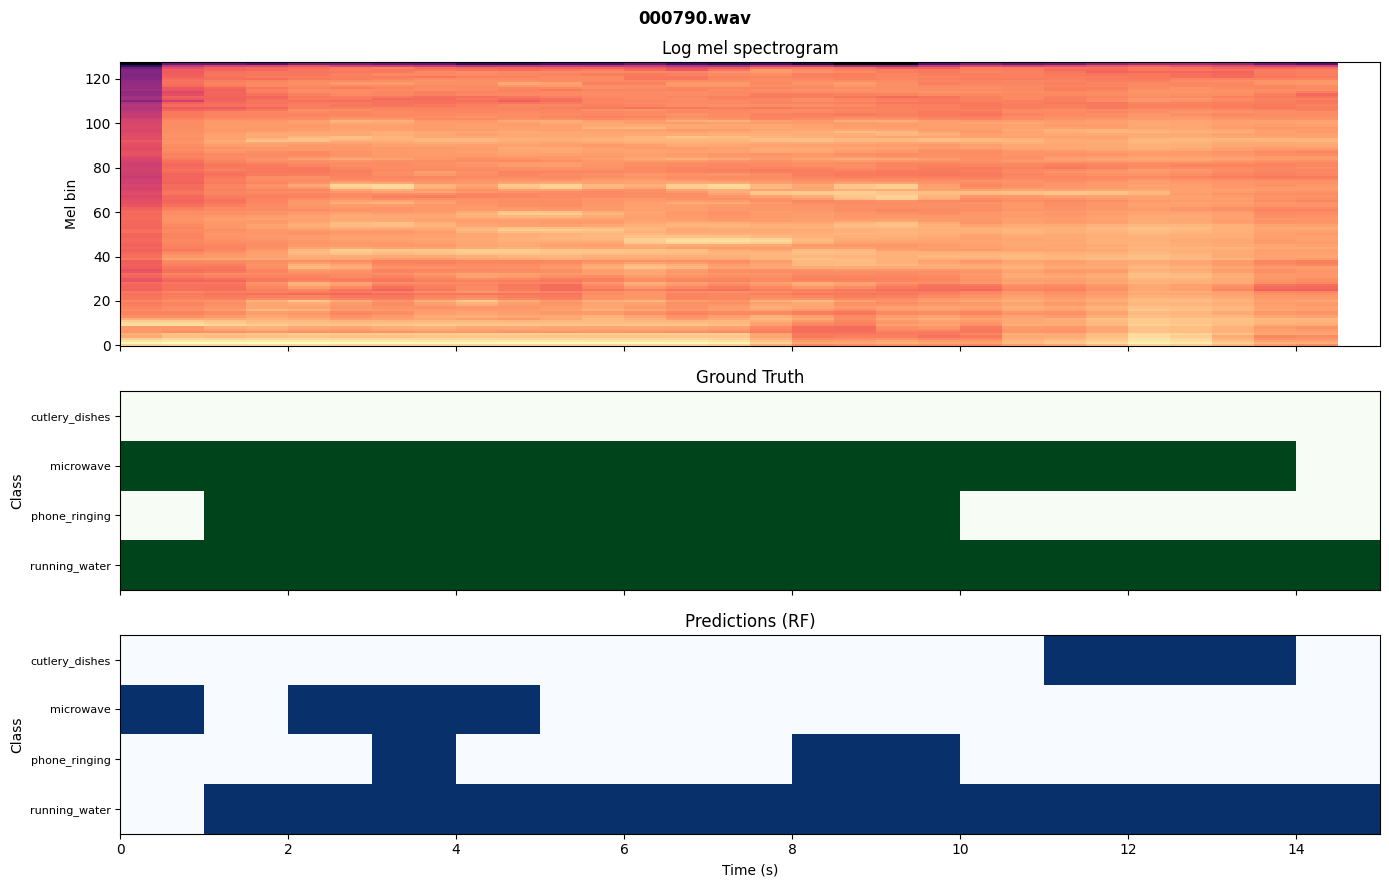


000790.wav — per active class:
  cutlery_dishes               TP=0 FN=0 FP=3
  microwave                    TP=4 FN=10 FP=0
  phone_ringing                TP=3 FN=6 FP=0
  running_water                TP=14 FN=1 FP=0


Saved case_confusion_005294.png


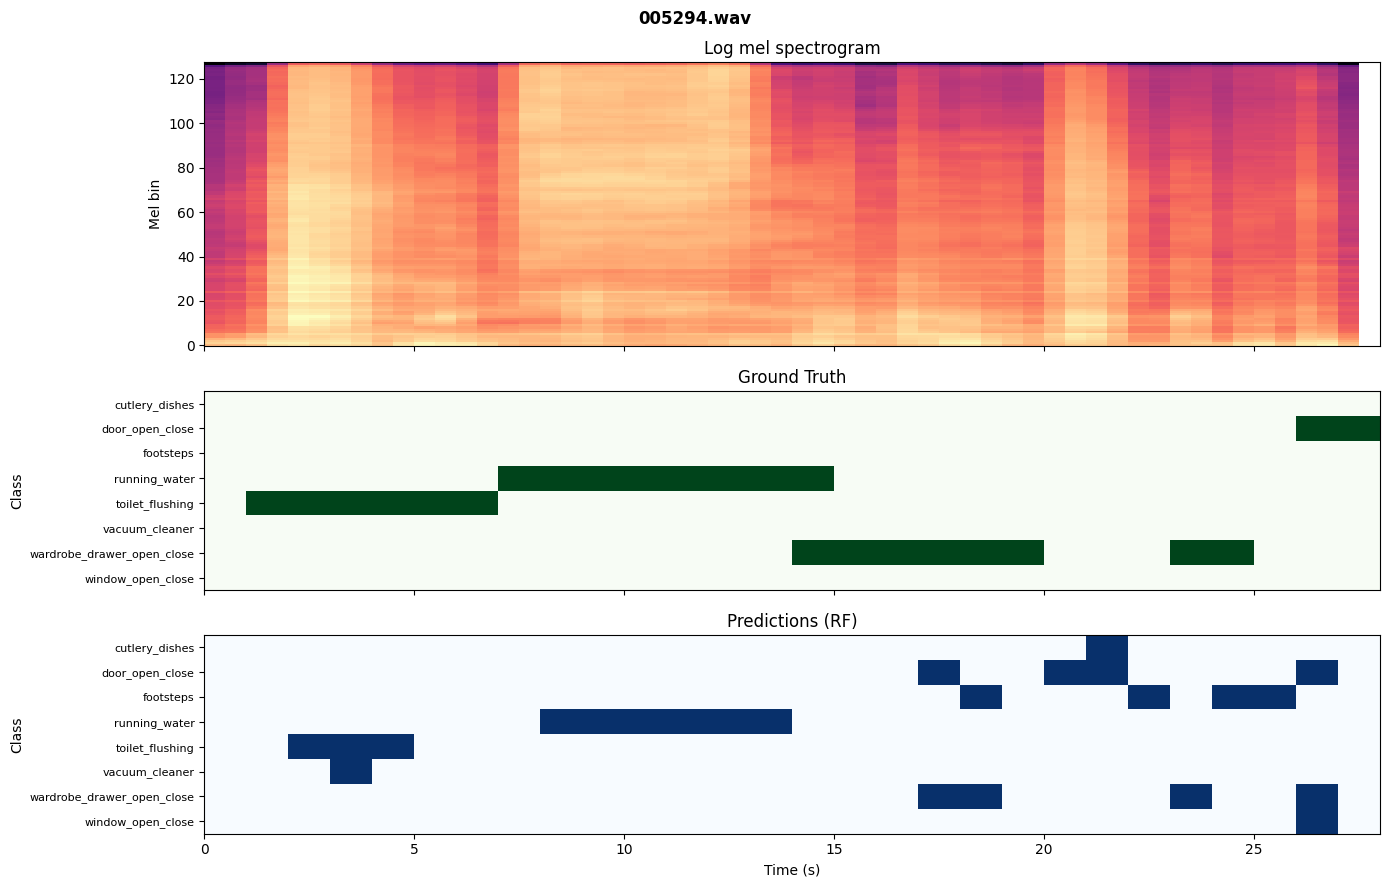


005294.wav — per active class:
  cutlery_dishes               TP=0 FN=0 FP=1
  door_open_close              TP=1 FN=1 FP=3
  footsteps                    TP=0 FN=0 FP=4
  running_water                TP=6 FN=2 FP=0
  toilet_flushing              TP=3 FN=3 FP=0
  vacuum_cleaner               TP=0 FN=0 FP=1
  wardrobe_drawer_open_close   TP=3 FN=5 FP=1
  window_open_close            TP=0 FN=0 FP=1


In [29]:
path_lookup = dict(zip(candidates['fname'], candidates['path']))

visualize_file(path_lookup['000790.wav'], rf_clf, save_name='case_success_000790.png')
print("\n" + "="*70 + "\n")
visualize_file(path_lookup['005294.wav'], rf_clf, save_name='case_confusion_005294.png')

In [28]:
# Which trained RF objects exist in memory?
for name in ['best_rf', 'best_rf_clf', 'rf', 'clf']:
    print(f"{name:12} ->", 'EXISTS' if name in dir() else 'missing')
path_lookup = dict(zip(candidates['fname'], candidates['path']))

best_rf      -> missing
best_rf_clf  -> missing
rf           -> EXISTS
clf          -> EXISTS


                                                       TASK 3

In [30]:
                   ###Task 3#####
from scipy.ndimage import median_filter

def apply_median_filter(pred_matrix, window):
    """Per-class temporal median filter over the per-second prediction matrix.
       pred_matrix: (T, C) binary. window: odd int >=1 (seconds). window=1 = no-op."""
    if window <= 1:
        return pred_matrix
    out = np.empty_like(pred_matrix)
    for c in range(pred_matrix.shape[1]):
        out[:, c] = median_filter(pred_matrix[:, c], size=window, mode='nearest')
    return out

def generate_predictions_pp(file_list, classifier, window=1):
    """Same as generate_predictions, but applies a median filter (size=window)
       to the whole-second prediction matrix before merging into intervals."""
    all_rows = []
    for filepath in file_list:
        preds, times, fname = run_sed_inference(filepath, classifier)  # (T,C) whole-second
        preds = apply_median_filter(preds, window)
        all_rows.extend(predictions_to_intervals(preds, times, fname))
    if not all_rows:
        return pd.DataFrame(columns=["filename","annotation","onset","offset"])
    return pd.DataFrame(all_rows)

print("Median filtering + PP inference ready.")

Median filtering + PP inference ready.


  window=1: macro F1 = 0.4714  (no post-processing)
  window=3: macro F1 = 0.4432  
  window=5: macro F1 = 0.4071  
  window=7: macro F1 = 0.3842  
  window=9: macro F1 = 0.3638  

Best window=1, macro F1=0.4714
Improvement over no-PP: +0.0000


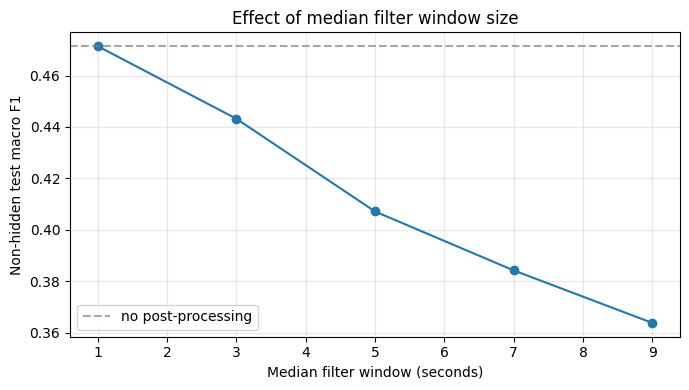

In [31]:
windows = [1, 3, 5, 7, 9]   # window=1 is the no-post-processing reference
pp_results = []

for w in windows:
    pred_w = generate_predictions_pp(our_test_files, rf_clf, window=w)
    mf1_w, _ = evaluate_split(pred_w, our_test_files, ann_df)
    pp_results.append({'window': w, 'macro_f1': mf1_w})
    tag = "(no post-processing)" if w == 1 else ""
    print(f"  window={w}: macro F1 = {mf1_w:.4f}  {tag}")

pp_df = pd.DataFrame(pp_results)
best_w = pp_df.loc[pp_df['macro_f1'].idxmax()]
print(f"\nBest window={int(best_w['window'])}, macro F1={best_w['macro_f1']:.4f}")
print(f"Improvement over no-PP: {best_w['macro_f1'] - pp_df.iloc[0]['macro_f1']:+.4f}")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(pp_df['window'], pp_df['macro_f1'], marker='o')
ax.axhline(pp_df.iloc[0]['macro_f1'], color='gray', ls='--', alpha=0.7, label='no post-processing')
ax.set_xlabel('Median filter window (seconds)'); ax.set_ylabel('Non-hidden test macro F1')
ax.set_title('Effect of median filter window size'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('median_filtering.png', dpi=150); plt.show()

In [32]:
# ---- Generate predictions for the hidden test set using our best system ----
# Best system = RF (depth=20, leaf=5, balanced), NO post-processing (window=1).
print(f"Generating predictions for {len(test_files)} hidden test recordings...")
pred_hidden = generate_predictions_pp(test_files, rf_clf, window=1)   # window=1 = no filtering
print(f"Done. {len(pred_hidden)} event intervals across "
      f"{pred_hidden['filename'].nunique()} files.")

OUTPUT_CSV = "predictions_hidden_test.csv"
pred_hidden.to_csv(OUTPUT_CSV, index=False)
print(f"Saved -> {OUTPUT_CSV}")

# ---- Self-validation (mirrors evaluate.py checks) ----
print("\n--- VALIDATION ---")
df = pd.read_csv(OUTPUT_CSV)

# 1. columns
required = {"filename","annotation","onset","offset"}
assert required.issubset(df.columns), f"Missing columns: {required - set(df.columns)}"
print("Columns OK:", list(df.columns))

# 2. class names all valid
bad = set(df["annotation"].unique()) - set(CLASS_NAMES)
assert not bad, f"Unexpected class labels: {bad}"
print(f"All {df['annotation'].nunique()} class labels valid.")

# 3. onset/offset sanity
assert (df["offset"] > df["onset"]).all(), "Found offset <= onset rows!"
assert (df["onset"] >= 0).all(), "Found negative onset!"
print("All intervals have offset > onset >= 0.")

# 4. filename format
assert df["filename"].str.endswith(".wav").all(), "Some filenames don't end in .wav"
print("All filenames end in .wav.")

# 5. coverage — how many hidden files got at least one prediction
hidden_names = {os.path.basename(f).replace(".npz",".wav") for f in test_files}
predicted_names = set(df["filename"].unique())
missing = hidden_names - predicted_names
print(f"\nHidden files: {len(hidden_names)} | with >=1 prediction: {len(predicted_names)} "
      f"| with NO predictions: {len(missing)}")

print("\n--- SAMPLE (first 8 rows) ---")
print(df.head(8).to_string(index=False))
print("\n--- per-class row counts ---")
print(df["annotation"].value_counts().to_string())

Generating predictions for 1007 hidden test recordings...


C:\Users\syedw\anaconda3\envs\mlpc2026\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\syedw\anaconda3\envs\mlpc2026\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\syedw\anaconda3\envs\mlpc2026\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\syedw\anaconda3\envs\mlpc2026\Lib\site-packages\s

Done. 7377 event intervals across 995 files.
Saved -> predictions_hidden_test.csv

--- VALIDATION ---
Columns OK: ['filename', 'annotation', 'onset', 'offset']
All 15 class labels valid.
All intervals have offset > onset >= 0.
All filenames end in .wav.

Hidden files: 1007 | with >=1 prediction: 995 | with NO predictions: 12

--- SAMPLE (first 8 rows) ---
  filename      annotation  onset  offset
000020.wav  cutlery_dishes    1.0     2.0
000020.wav  cutlery_dishes    3.0     4.0
000020.wav door_open_close    2.0     3.0
000020.wav door_open_close    5.0     6.0
000020.wav door_open_close   21.0    22.0
000020.wav       footsteps    6.0    11.0
000020.wav       footsteps   12.0    13.0
000020.wav       footsteps   15.0    20.0

--- per-class row counts ---
annotation
footsteps                     1447
door_open_close               1014
keyboard_typing                670
cutlery_dishes                 668
running_water                  590
keychain                       525
window_open_c